# Lab 2.2: SARSA (TD Methods)

 ## Introduction

 In this lab, we will implement the temporal difference method to estimate the Q-function for each state over time, updating the policy along the way.  
 This kinda reminds me of finite difference methods of estimating derivatives, or Taylor series approximations: instead of taking the whole series (episode) we can take the first `n` terms of it to get a reasonable estimate.



 ## Student Information

 **Name:** Kevin Cotellesso

 **Date:** 3-25-2026

 ---

Set up the environment:

In [3]:
import numpy as np
from tqdm import tqdm
import gymnasium as gym

env = gym.make('FrozenLake-v1', map_name="4x4", is_slippery=True)
n_state = env.unwrapped.observation_space.n
n_action = env.unwrapped.action_space.n
print("# of actions:", n_action)
print("# of states:", n_state)

# of actions: 4
# of states: 16


In [6]:

def run_episode(env, policy):
    """Run one episode and return the trajectory (states, actions, rewards)."""

    obs = env.reset()[0]
    states, actions, rewards = [], [], []
    while True:
        states.append(obs)
        action = int(policy(obs))
        actions.append(action)
        obs, reward, done, truncated, _ = env.step(action)
        rewards.append(reward)
        if done or truncated:
            break
    return states, actions, rewards

---
# Part 1: TD(1), one-step SARSA
Let's begin now.

In [8]:
# Epsilon greedy policy for one-step SARSA
class EpsilonGreedyPolicy:
    def __init__(self, Q, eps, gamma=0.98, alpha=0.01):
        self.Q = Q          # Q-table: Q[state, action]
        self.eps = eps       # Exploration rate
        self.gamma = gamma   # Discount factor
        self.alpha = alpha

    # SARSA = State (obs), Action, Reward, next State, next Action
    def update(self, obs, act, reward, next_obs, next_act):
        """Update Q-values using returns computed from an episode step."""
        # NOTE: We have full observability in this case so obs = state.
        # This performs TD(1) or 1 step SARSA
        TD_target = reward + self.gamma*self.Q[next_obs, next_act] # Estimated Q for current obs/action:
        # reward for this obs/action plus Q for next obs/action we made
        TD_error = TD_target - self.Q[obs, act] # Difference in estimated and actual Q-function
        self.Q[obs, act] += self.alpha*TD_error # Adjust actual (current) Q-function. Note that if alpha = 1, we are just setting current state/action Q to TD_target.


    def __call__(self, state):
        """Select action using epsilon-greedy."""
        if np.random.rand() < self.eps:
            return np.random.choice(n_action)
        return np.argmax(self.Q[state, :])
    

In [9]:
Q = np.zeros((n_state, n_action)) # Initialize Q function with zeros.
policy = EpsilonGreedyPolicy(Q, eps=1.0)
reward_list = []
n_episodes = 20000
for i in tqdm(range(n_episodes)):
    obs, _ = env.reset()
    act = -1
    while True:
        # Take an action, and record our next action
        if(act == -1):
            act = policy(obs)
        
        next_obs, reward, done, truncated, _ = env.step(act)
        next_act = policy(next_obs)
        policy.update(obs, act, reward, next_obs, next_act)
        if done or truncated:
            break

        obs = next_obs
        act = next_act # I added this. Seems more honest
    policy.eps = max(0.01, policy.eps - 1.0/n_episodes)
    mean_reward = np.mean([sum(run_episode(env, policy)[2])
                          for _ in range(2)])
    reward_list.append(mean_reward)

policy.eps = 0.0
scores = [sum(run_episode(env, policy)[2]) for _ in range(100)]
print("Final score: {:.2f}".format(np.mean(scores)))

import pandas as pd
df = pd.DataFrame({'reward': reward_list})
df.to_csv("./SARSA_1.csv", index=False, header=True)

100%|██████████| 20000/20000 [00:10<00:00, 1930.49it/s]

Final score: 0.61


In [17]:
policy.eps = 0.0
scores = [sum(run_episode(env, policy)[2]) for _ in range(100)]
print("Final score: {:.2f}".format(np.mean(scores)))

Final score: 0.60


---
# Part 2: TD(n), n-step SARSA
Let's get to work.

In [25]:
from collections import deque

class NStepSarsaPolicy:
    def __init__(self, Q, eps, n_step, gamma=0.98, lr=0.01):
        self.Q = Q
        self.eps = eps
        self.n_step = n_step
        self.gamma = gamma
        self.lr = lr
        # Fixed-size buffer: automatically discards oldest when full
        self.buffer = deque(maxlen=n_step) # Holds enough episode data to use n steps for a better estimate of Q function

    def reset_buffer(self):
        """Call at the start of each episode."""
        self.buffer.clear()

    def update(self, obs, act, reward, next_obs, next_act, done):
        # Push new transition; if buffer is already full, the oldest
        # is automatically pushed out (deque with maxlen)
        self.buffer.append((obs, act, reward))
        # if(reward != 0):
        #     print("Got nonzero reward!")

        # Normal case: buffer is full, not end of episode
        if not done and len(self.buffer) == self.n_step:
            # TODO: compute n-step return G from all n rewards in buffer
            # G = r_0 + γr_1 + ... + γ^(n-1)r_{n-1} + γ^n * Q(next_obs, next_act)
            # Update Q for the oldest (s, a) in buffer: buffer[0]

            G = 0
            for i in range(self.n_step):
                # Add on the ith term to G
                reward = self.buffer[i][2]
                G+=reward*self.gamma**i
            # Finally, add on the estimation of remaining rewards (the Q function at the most recent obs)
            # if(self.Q[next_obs, next_act]>0):
            #     pass
            G+=self.Q[next_obs, next_act]*self.gamma**self.n_step 

            # Update Q function (from the start of the queue)
            obs_temp = self.buffer[0][0]
            act_temp = self.buffer[0][1]
            self.Q[obs_temp][act_temp] += self.lr*(G-self.Q[obs_temp][act_temp])


        # End of episode: process ALL remaining entries in the buffer
        elif done:
            # Loop through every entry in the buffer (index 0, 1, ...).
            # For each entry at index idx, compute the return from the
            # rewards at buffer[idx], buffer[idx+1], ..., buffer[-1].
            # No bootstrap (terminal state). Update Q for buffer[idx].
            for i in range(len(self.buffer)):
                # Compute the rewards remaining for step i and beyond
                G = 0
                steps = 0
                for j in range(i, len(self.buffer)): #i, i+1, ... n-1
                    # Ri + gamma*Ri+1 + ...
                    G += self.buffer[j][2]*(self.gamma**steps)
                    steps+=1
                # At this point G holds discounted rewards from i to termination.
                # Update the Q function at that point.
                obs_temp = self.buffer[i][0]
                act_temp = self.buffer[i][1]
                self.Q[obs_temp][act_temp] += self.lr*(G-self.Q[obs_temp][act_temp])


    def __call__(self, state):
        if np.random.rand() < self.eps: # eps percent of the time, we take random action.
            return np.random.choice(n_action)
        return np.argmax(self.Q[state, :]) # The rest of the time, take what we think is the best action.

Train the n-SARSA.

In [32]:
Q = np.zeros((n_state, n_action)) # Initialize Q function with zeros.
policy = NStepSarsaPolicy(Q, eps=1.0, n_step=25)
reward_list = []
n_episodes = 20000
for i in tqdm(range(n_episodes)):
    obs, _ = env.reset()
    act = -1
    while True:
        # Take an action, and record our next action
        if(act == -1):
            act = policy(obs)
        
        next_obs, reward, done, truncated, _ = env.step(act)
        next_act = policy(next_obs)
        policy.update(obs, act, reward, next_obs, next_act, done)
        if done or truncated:
            break

        obs = next_obs
        act = next_act # I added this. Seems more honest
    policy.eps = max(0.01, policy.eps - 1.0/n_episodes)
    mean_reward = np.mean([sum(run_episode(env, policy)[2])
                          for _ in range(2)])
    reward_list.append(mean_reward)


import pandas as pd
df = pd.DataFrame({'reward': reward_list})
df.to_csv(f"./SARSA_{policy.n_step}.csv", index=False, header=True)

100%|██████████| 20000/20000 [00:08<00:00, 2410.33it/s]


In [33]:
policy.eps = 0.0
scores = [sum(run_episode(env, policy)[2]) for _ in range(100)]
print("Final score: {:.2f}".format(np.mean(scores)))

Final score: 0.58


---
# Part 3: $SARSA(\lambda)$
$SARSA(\lambda)$ is a method that updates Q-value for any state-action pair that contributed to a reward. For example, if you are in state 0 and do action 1 and eventually you get to the goal in that episode, the Q for that state,action will be increased slightly.  
Of course, if you are in state 14 and do action 2 and get to the goal (state 15), the Q for that state,action will be increased a larger amount.  
This is completed using an "eligibility trace" - essentially a track of "where you've been".  
Any state,action that is visited,performed by an agent has its "eligibility" increased to (or by) 1.0. Every step the agent takes after that, the eligibility of that state decreases slightly (using $\lambda$). In this way, a record of which state-actions contributed to a reward is kept. Once that reward is reached, every state-action in the trace is updated.

In [4]:
class SarsaLambdaPolicy:
    def __init__(self, Q, eps, lam=0.8, gamma=0.98, lr=0.01):
        self.Q = Q
        self.eps = eps
        self.lam = lam       # λ: trace decay parameter
        self.gamma = gamma
        self.lr = lr
        # Eligibility traces: same shape as Q (stores "eligibility" for every state,action pair)
        self.E = np.zeros_like(Q)

    def reset_traces(self):
        """Call at the start of each episode."""
        # reset all traces to 0.
        self.E = np.zeros_like(Q)


    def update(self, obs, act, reward, next_obs, next_act):
        """Apply the 4-step update described above:
        1. Compute TD error δ
                # This performs TD(1) or 1 step SARSA
        2. Increment trace for visited (s, a)
        3. Update ALL Q-values proportional to their trace
        4. Decay ALL traces by γλ
        """
        # 1. Compute one-step TD error
        TD_target = reward + self.gamma*self.Q[next_obs, next_act] # Estimated Q for current obs/action:
        # reward for this obs/action plus Q for next obs/action we made
        TD_error = TD_target - self.Q[obs, act] # Difference in estimated and actual Q-function

        # 2. Increment trace for visited state,action
        self.E[obs][act] += 1.0

        # 3. Update ALL Q-values from the TD(1) we calculated
        self.Q = self.Q + self.lr*TD_error*self.E

        # 4. Decay all traces. The farther away agent is from a given s,a the less say that s,a had in getting a reward
        self.E = self.gamma*self.lam*self.E


    def __call__(self, state):
        if np.random.rand() < self.eps:
            return np.random.choice(n_action)
        return np.argmax(self.Q[state, :])

Training loop for $SARSA(\lambda)$ is the same as for 1-step Sarsa.

In [18]:
Q = np.zeros((n_state, n_action)) # Initialize Q function with zeros.
policy = SarsaLambdaPolicy(Q, eps=1.0)
reward_list = []
n_episodes = 20000
for i in tqdm(range(n_episodes)):
    obs, _ = env.reset()
    act = -1
    while True:
        # Take an action, and record our next action
        if(act == -1):
            act = policy(obs)
        
        next_obs, reward, done, truncated, _ = env.step(act)
        next_act = policy(next_obs)
        policy.update(obs, act, reward, next_obs, next_act)
        if done or truncated:
            break

        obs = next_obs
        act = next_act # I added this. Seems more honest
    policy.reset_traces() # Set eligibility trace to zeros in preparation for the next 
    policy.eps = max(0.01, policy.eps - 1.0/n_episodes) # Make it a little less likely to choose randomly
    mean_reward = np.mean([sum(run_episode(env, policy)[2])
                          for _ in range(2)])
    reward_list.append(mean_reward)

policy.eps = 0.0
scores = [sum(run_episode(env, policy)[2]) for _ in range(100)]
print("Final score: {:.2f}".format(np.mean(scores)))

import pandas as pd
df = pd.DataFrame({'reward': reward_list})
df.to_csv("./SARSA_lambda.csv", index=False, header=True)

100%|██████████| 20000/20000 [00:11<00:00, 1808.62it/s]


Final score: 0.73


---
# Part 4: Questions!  

1. Learning curves for 1-step, 2-step, 5-step and lambda sarsa

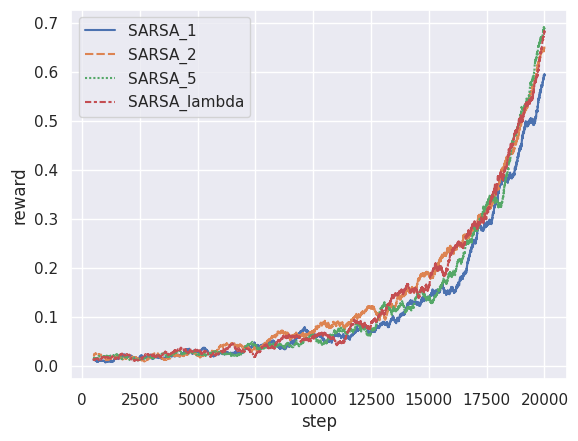

In [23]:
import plot
import seaborn as sns
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
df = plot.read_data(".", y='reward', smooth=500)
sns.lineplot(data=df, x="step", y="reward", hue="tag", style="tag")
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles, labels=labels)
plt.show()

2. *Compare Sarsa with different step sizes. What are the pros and cons of n-step Sarsa with a large n? What happens as n→∞?*  


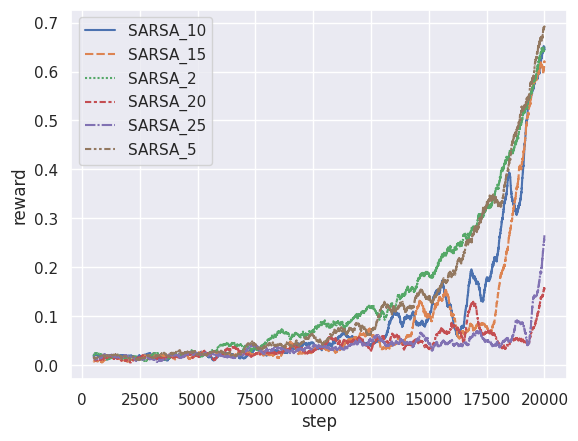

In [35]:
fig, ax = plt.subplots()
df = plot.read_data("nstep_tests", y='reward', smooth=500)
sns.lineplot(data=df, x="step", y="reward", hue="tag", style="tag")
handles, labels = ax.get_legend_handles_labels()
labels, handles = zip(*sorted(zip(labels, handles), key=lambda t: t[0]))
ax.legend(handles=handles, labels=labels)
plt.show()

SARSA-2 and SARSA-5 seem to perform the best. SARSA-10 and SARSA-15 take longer but eventually get to the same level of performance. SARSA-20 and SARSA-25 offer significantly degraded performance, likely because the episodes are terminating before any updates can happen (due to the large buffer). As n approaches infinity, n-step sarsa approaches monte carlo behavior, where everything touched gets updated at the end of the episode. Larger n sarsa has the advantage of being able to see farther into the future when updating a Q value, which would provide more accurate estimates quicker if there were rewards at every step.  


3. *Compare Sarsa(λ) with n-step Sarsa. What advantage does the eligibility trace approach have over fixing a single n?*  
Sarsa(λ) seems to be well suited to sparse reward environments like FrozenLake; as soon as a reward is hit, every state-action that led up to it gets a bump in Q proportional to how closely it preceded the reward. The eligibility trace is key in making sure state-action pairs that actually contributed to the reward are "rewarded" properly. Fixing a single n limits how fast rewards can propagate through the Q matrix, making it hard to find a reward again once it is found.